
## Feature Engineering


**Input:** `data/processed/matches_clean.csv` (from Notebook 1)

**Output:** `data/processed/features.csv` — one row per match, ready for XGBoost



## 1. Load clean data

In [ ]:
import os
os.makedirs('data/processed', exist_ok=True)

In [ ]:
from google.colab import files

print('Upload your 3 CSV files:')
uploaded = files.upload()

for filename, content in uploaded.items():
    with open(f'data/processed/{filename}', 'wb') as f:
        f.write(content)
    print(f'✅ Saved: data/processed/{filename}')

Upload your 3 CSV files:


Saving worldcup_matches.csv to worldcup_matches.csv
Saving rankings_clean.csv to rankings_clean.csv
Saving matches_clean.csv to matches_clean.csv
✅ Saved: data/processed/worldcup_matches.csv
✅ Saved: data/processed/rankings_clean.csv
✅ Saved: data/processed/matches_clean.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/processed/matches_clean.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Loaded {len(df):,} matches')
print(f'Date range: {df.date.min().date()} → {df.date.max().date()}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Loaded 31,929 matches
Date range: 1916-07-02 → 2026-06-18
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral', 'outcome', 'is_world_cup', 'is_neutral', 'home_fifa_rank', 'home_fifa_points', 'away_fifa_rank', 'away_fifa_points', 'rank_diff', 'points_diff', 'year']


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,outcome,is_world_cup,is_neutral,home_fifa_rank,home_fifa_points,away_fifa_rank,away_fifa_points,rank_diff,points_diff,year
0,1916-07-02,Chile,Uruguay,0,4,Copa América,Buenos Aires,Argentina,True,A,False,True,NaN,NaN,NaN,NaN,NaN,NaN,1916
1,1916-07-06,Argentina,Chile,6,1,Copa América,Buenos Aires,Argentina,False,H,False,False,NaN,NaN,NaN,NaN,NaN,NaN,1916
2,1916-07-08,Brazil,Chile,1,1,Copa América,Buenos Aires,Argentina,True,D,False,True,NaN,NaN,NaN,NaN,NaN,NaN,1916


## 2. Time decay & competition weights

### Why time decay?
A match from 1930 tells us almost nothing about a team in 2026 — different players, coaches, tactics, even rules. We use **exponential decay** to discount old matches:

```
weight = e^(−λ × years_ago)
```

With λ = 0.1:
- Match yesterday → weight ≈ 1.0
- 5 years ago     → weight ≈ 0.60
- 10 years ago    → weight ≈ 0.37
- 30 years ago    → weight ≈ 0.05
- 1930            → weight ≈ 0.000

So old data isn't thrown away — it just barely registers. Modern matches dominate.

### Why competition weights?
A 6-0 win over a Pacific island in a friendly ≠ a 1-0 win over Germany in a World Cup final. We multiply by competition importance so the model knows the difference.

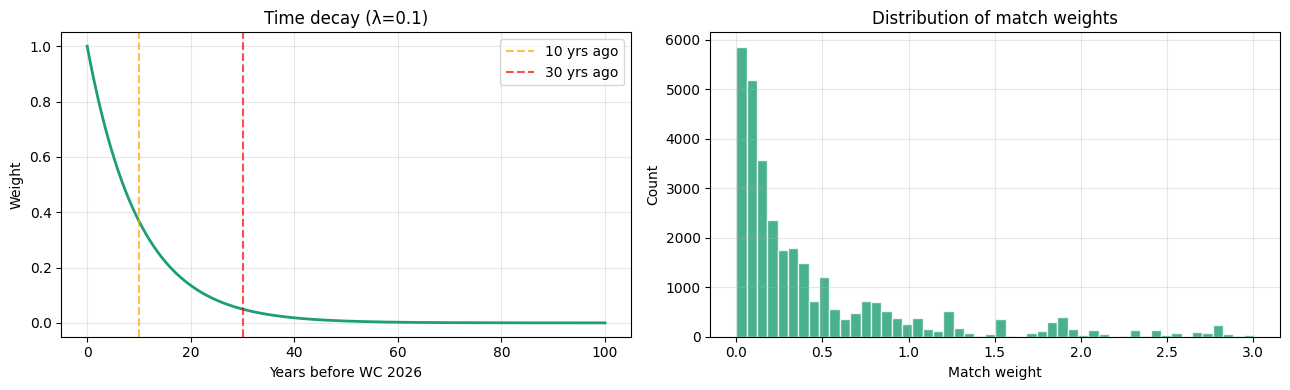

Weight range: 0.0000 → 3.01


In [ ]:
# ── Reference date: today (predictions are for WC 2026) ──
REF_DATE = pd.Timestamp('2026-06-11')  # WC 2026 start date
LAMBDA   = 0.1                         # decay rate (tune this later)

df['years_ago']    = (REF_DATE - df['date']).dt.days / 365.25
df['time_weight']  = np.exp(-LAMBDA * df['years_ago'])

# ── Competition weights ──
# Higher = more important = more signal
COMP_WEIGHTS = {
    'FIFA World Cup':              3.0,
    'UEFA Euro':                   2.5,
    'Copa América':                2.5,
    'Copa América Centenario':     2.5,
    'Africa Cup of Nations':       2.2,
    'AFC Asian Cup':               2.2,
    'CONCACAF Gold Cup':           2.0,
    'Confederations Cup':          2.0,
    'UEFA Nations League':         1.8,
    'FIFA World Cup qualification':1.5,
    'Friendly':                    0.5,
}
def get_comp_weight(tournament):
    for key, w in COMP_WEIGHTS.items():
        if key.lower() in str(tournament).lower():
            return w
    return 1.0   # default for unknown tournaments

df['comp_weight']  = df['tournament'].apply(get_comp_weight)
df['match_weight'] = df['time_weight'] * df['comp_weight']

# ── Visualise decay ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Time decay curve
years = np.linspace(0, 100, 300)
axes[0].plot(years, np.exp(-LAMBDA * years), color='#1D9E75', linewidth=2)
axes[0].axvline(10, color='orange', linestyle='--', alpha=0.7, label='10 yrs ago')
axes[0].axvline(30, color='red',    linestyle='--', alpha=0.7, label='30 yrs ago')
axes[0].set_xlabel('Years before WC 2026'); axes[0].set_ylabel('Weight')
axes[0].set_title(f'Time decay (λ={LAMBDA})')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Match weight distribution
axes[1].hist(df['match_weight'], bins=50, color='#1D9E75', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Match weight'); axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of match weights')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Weight range: {df.match_weight.min():.4f} → {df.match_weight.max():.2f}')

## 3. Rolling form features

For each match, we look back at each team's **last N matches** (before this match date) and compute:
- `form_win_rate` — weighted % of wins
- `form_draw_rate` — weighted % of draws  
- `form_goals_scored_avg` — weighted avg goals scored
- `form_goals_conceded_avg` — weighted avg goals conceded
- `form_goal_diff_avg` — scored − conceded
- `form_sos` — strength of schedule (avg opponent FIFA points)

All weighted by `match_weight` so recent important games count more.

> ⚠️ We always look **backwards only** (matches strictly before the current date). No data leakage.

In [ ]:
FORM_WINDOW = 10   # last N matches to consider

def compute_team_form(team, before_date, df, n=FORM_WINDOW):
    """
    For a given team, compute weighted form stats from their last N matches
    strictly before before_date.
    Returns a dict of features.
    """
    # All matches this team played (home or away), before this date
    home_mask = (df['home_team'] == team) & (df['date'] < before_date)
    away_mask = (df['away_team'] == team) & (df['date'] < before_date)
    team_matches = df[home_mask | away_mask].tail(n).copy()

    if len(team_matches) == 0:
        return {k: np.nan for k in [
            'win_rate','draw_rate','loss_rate',
            'goals_scored_avg','goals_conceded_avg','goal_diff_avg',
            'sos','n_matches'
        ]}

    records = []
    for _, row in team_matches.iterrows():
        is_home   = (row['home_team'] == team)
        scored    = row['home_score']    if is_home else row['away_score']
        conceded  = row['away_score']    if is_home else row['home_score']
        opp_pts   = row['away_fifa_points'] if is_home else row['home_fifa_points']
        outcome   = row['outcome']
        win  = 1 if (is_home and outcome=='H') or (not is_home and outcome=='A') else 0
        draw = 1 if outcome == 'D' else 0
        loss = 1 if (is_home and outcome=='A') or (not is_home and outcome=='H') else 0
        w = row['match_weight']
        records.append({
            'win':w*win, 'draw':w*draw, 'loss':w*loss,
            'scored':w*scored, 'conceded':w*conceded,
            'opp_pts':opp_pts if pd.notna(opp_pts) else np.nan,
            'w': w
        })

    r   = pd.DataFrame(records)
    W   = r['w'].sum()
    sos = r['opp_pts'].mean()  # simple mean, not weighted (opponent quality)

    return {
        'win_rate':           r['win'].sum()      / W,
        'draw_rate':          r['draw'].sum()     / W,
        'loss_rate':          r['loss'].sum()     / W,
        'goals_scored_avg':   r['scored'].sum()   / W,
        'goals_conceded_avg': r['conceded'].sum() / W,
        'goal_diff_avg':      (r['scored'].sum() - r['conceded'].sum()) / W,
        'sos':                sos,
        'n_matches':          len(r)
    }

# Test it
test = compute_team_form('Brazil', pd.Timestamp('2026-01-01'), df)
print('Brazil form (before Jan 2026):')
for k, v in test.items():
    print(f'  {k:25s} {v:.3f}' if isinstance(v, float) else f'  {k:25s} {v}')

Brazil form (before Jan 2026):
  win_rate                  0.487
  draw_rate                 0.171
  loss_rate                 0.342
  goals_scored_avg          1.322
  goals_conceded_avg        1.038
  goal_diff_avg             0.284
  sos                       1555.054
  n_matches                 10


In [ ]:
# ── Build form features for EVERY match (this is the slow step ~2-5 min) ──
print(f'Computing form for {len(df):,} matches × 2 teams...')
print('This takes 2-5 minutes. Go make a chai. ☕')

home_forms, away_forms = [], []

for i, row in enumerate(df.itertuples()):
    if i % 5000 == 0:
        print(f'  {i:,} / {len(df):,}')
    home_forms.append(compute_team_form(row.home_team, row.date, df))
    away_forms.append(compute_team_form(row.away_team, row.date, df))

home_form_df = pd.DataFrame(home_forms).add_prefix('home_form_')
away_form_df = pd.DataFrame(away_forms).add_prefix('away_form_')

df = pd.concat([df, home_form_df, away_form_df], axis=1)
print(f'\n✅ Form features added. Shape: {df.shape}')

Computing form for 31,929 matches × 2 teams...
This takes 2-5 minutes. Go make a chai. ☕
  0 / 31,929
  5,000 / 31,929
  10,000 / 31,929
  15,000 / 31,929
  20,000 / 31,929
  25,000 / 31,929
  30,000 / 31,929

✅ Form features added. Shape: (31929, 39)


## 4. Head-to-head features

Rolling H2H between **these specific two teams** — last 5 meetings only.
Recent H2H matters psychologically and tactically (teams study each other).

In [ ]:
H2H_WINDOW = 5

def compute_h2h(home, away, before_date, df, n=H2H_WINDOW):
    """
    Last N meetings between home and away, before before_date.
    Returns home win rate, draw rate, goals scored avg from home's perspective.
    """
    mask = (
        ((df['home_team']==home) & (df['away_team']==away)) |
        ((df['home_team']==away) & (df['away_team']==home))
    ) & (df['date'] < before_date)

    meetings = df[mask].tail(n)

    if len(meetings) == 0:
        return {'h2h_home_win_rate': np.nan, 'h2h_draw_rate': np.nan,
                'h2h_home_goals_avg': np.nan, 'h2h_away_goals_avg': np.nan,
                'h2h_n': 0}

    results = []
    for _, row in meetings.iterrows():
        if row['home_team'] == home:
            win  = 1 if row['outcome'] == 'H' else 0
            draw = 1 if row['outcome'] == 'D' else 0
            hg, ag = row['home_score'], row['away_score']
        else:  # home team was playing away in this historical match
            win  = 1 if row['outcome'] == 'A' else 0
            draw = 1 if row['outcome'] == 'D' else 0
            hg, ag = row['away_score'], row['home_score']
        results.append({'win': win, 'draw': draw, 'hg': hg, 'ag': ag})

    r = pd.DataFrame(results)
    return {
        'h2h_home_win_rate':  r['win'].mean(),
        'h2h_draw_rate':      r['draw'].mean(),
        'h2h_home_goals_avg': r['hg'].mean(),
        'h2h_away_goals_avg': r['ag'].mean(),
        'h2h_n':              len(r)
    }

print('Computing H2H features...')
h2h_records = [
    compute_h2h(row.home_team, row.away_team, row.date, df)
    for row in df.itertuples()
]
h2h_df = pd.DataFrame(h2h_records)
df = pd.concat([df, h2h_df], axis=1)
print(f'✅ H2H features added. Matches with H2H data: {(df.h2h_n > 0).sum():,}')

Computing H2H features...
✅ H2H features added. Matches with H2H data: 25,010


## 5. Encode categorical features

In [ ]:
# ── Tournament stage weight (numeric, not one-hot) ──
df['tournament_weight'] = df['tournament'].apply(get_comp_weight)

# ── Confederation of each team ──
UEFA = ['England','France','Germany','Spain','Italy','Portugal','Netherlands',
        'Belgium','Croatia','Denmark','Switzerland','Poland','Sweden','Ukraine',
        'Austria','Czech Republic','Serbia','Hungary','Scotland','Wales','Norway',
        'Turkey','Greece','Romania','Slovakia','Slovenia','Albania','Kosovo',
        'Bosnia and Herzegovina','Montenegro','North Macedonia','Georgia',
        'Finland','Ireland','Iceland','Luxembourg','Cyprus','Malta','Andorra',
        'San Marino','Liechtenstein','Faroe Islands','Estonia','Latvia',
        'Lithuania','Belarus','Moldova','Armenia','Azerbaijan']

CONMEBOL = ['Brazil','Argentina','Colombia','Uruguay','Chile','Ecuador',
            'Peru','Venezuela','Paraguay','Bolivia']

CONCACAF = ['Mexico','USA','Canada','Costa Rica','Honduras','Jamaica',
            'Panama','Haiti','Trinidad and Tobago','El Salvador','Guatemala',
            'Curacao','Cuba','Belize']

CAF = ['Morocco','Senegal','Nigeria','Ghana','Cameroon','Egypt','Ivory Coast',
       'Mali','Tunisia','Algeria','South Africa','DR Congo','Kenya','Ethiopia',
       'Zambia','Zimbabwe','Uganda','Tanzania','Mozambique','Angola','Cape Verde',
       'Burkina Faso','Benin','Guinea','Gabon','Equatorial Guinea']

AFC = ['Japan','South Korea','Iran','Saudi Arabia','Australia','Qatar',
       'Iraq','UAE','Uzbekistan','Tajikistan','Jordan','Bahrain','Oman',
       'Kuwait','China','India','Thailand','Vietnam','Indonesia','Syria']

OFC = ['New Zealand','Fiji','Papua New Guinea','Solomon Islands','Vanuatu']

def get_confederation(team):
    if team in UEFA:     return 'UEFA'
    if team in CONMEBOL: return 'CONMEBOL'
    if team in CONCACAF: return 'CONCACAF'
    if team in CAF:      return 'CAF'
    if team in AFC:      return 'AFC'
    if team in OFC:      return 'OFC'
    return 'UNKNOWN'

df['home_conf'] = df['home_team'].apply(get_confederation)
df['away_conf'] = df['away_team'].apply(get_confederation)
df['same_conf'] = (df['home_conf'] == df['away_conf']).astype(int)

# One-hot encode confederation (drop_first to avoid multicollinearity)
conf_dummies = pd.get_dummies(df['home_conf'], prefix='home_conf').astype(int)
df = pd.concat([df, conf_dummies], axis=1)

# ── is_neutral already exists, cast to int ──
df['is_neutral'] = df['is_neutral'].astype(int)

print('Confederations assigned:')
print(df['home_conf'].value_counts())
print(f'\nSame-confederation matches: {df.same_conf.sum():,}')

Confederations assigned:
home_conf
UNKNOWN     9581
UEFA        8300
AFC         4449
CAF         4446
CONMEBOL    2508
CONCACAF    2291
OFC          354
Name: count, dtype: int64

Same-confederation matches: 18,923


## 6. Derived difference features

In [ ]:
# These 'difference' features are often the most powerful in tree models
# because they directly encode relative advantage

df['form_win_rate_diff']      = df['home_form_win_rate']          - df['away_form_win_rate']
df['form_goal_diff_diff']     = df['home_form_goal_diff_avg']     - df['away_form_goal_diff_avg']
df['form_goals_scored_diff']  = df['home_form_goals_scored_avg']  - df['away_form_goals_scored_avg']
df['form_goals_conceded_diff']= df['home_form_goals_conceded_avg']- df['away_form_goals_conceded_avg']
df['sos_diff']                = df['home_form_sos']               - df['away_form_sos']

# rank_diff and points_diff already exist from Notebook 1

print('Difference features created:')
diff_cols = [c for c in df.columns if c.endswith('_diff')]
print(df[diff_cols].describe().round(3))

Difference features created:
       rank_diff  points_diff  form_win_rate_diff  form_goal_diff_diff  \
count  26633.000    26639.000           31642.000            31642.000   
mean       3.403       14.635               0.013                0.098   
std       53.702      266.645               0.294                1.835   
min     -210.000    -1757.000              -1.000              -20.097   
25%      -29.000     -102.000              -0.186               -0.904   
50%        4.000        7.000               0.010                0.082   
75%       36.000      139.000               0.211                1.080   
max      209.000     1596.000               1.000               18.912   

       form_goals_scored_diff  form_goals_conceded_diff   sos_diff  
count               31642.000                 31642.000  29648.000  
mean                    0.046                    -0.052      6.754  
std                     1.009                     1.180    146.739  
min                   -14.61

## 7. Final feature matrix — select and validate

In [ ]:
# ── These are the exact columns the model will train on ──
FEATURE_COLS = [
    # Team quality (FIFA)
    'home_fifa_rank', 'away_fifa_rank',
    'home_fifa_points', 'away_fifa_points',
    'rank_diff', 'points_diff',

    # Home team form
    'home_form_win_rate', 'home_form_draw_rate', 'home_form_loss_rate',
    'home_form_goals_scored_avg', 'home_form_goals_conceded_avg',
    'home_form_goal_diff_avg', 'home_form_sos',

    # Away team form
    'away_form_win_rate', 'away_form_draw_rate', 'away_form_loss_rate',
    'away_form_goals_scored_avg', 'away_form_goals_conceded_avg',
    'away_form_goal_diff_avg', 'away_form_sos',

    # Difference features (relative advantage)
    'form_win_rate_diff', 'form_goal_diff_diff',
    'form_goals_scored_diff', 'form_goals_conceded_diff', 'sos_diff',

    # Head-to-head
    'h2h_home_win_rate', 'h2h_draw_rate',
    'h2h_home_goals_avg', 'h2h_away_goals_avg', 'h2h_n',

    # Match context
    'is_neutral', 'tournament_weight', 'same_conf',

    # Confederation one-hots
    'home_conf_UEFA', 'home_conf_CONMEBOL', 'home_conf_CONCACAF',
    'home_conf_CAF', 'home_conf_AFC',
]

# Only keep cols that actually exist
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

TARGET_COL = 'outcome'     # H / D / A
WEIGHT_COL = 'match_weight'

feat_df = df[FEATURE_COLS + [TARGET_COL, WEIGHT_COL,
             'date', 'home_team', 'away_team', 'is_world_cup']].copy()

print(f'Feature matrix shape: {feat_df.shape}')
print(f'\nFeatures ({len(FEATURE_COLS)} total):')
for i, c in enumerate(FEATURE_COLS):
    null_pct = feat_df[c].isnull().mean() * 100
    print(f'  {i+1:2d}. {c:35s}  nulls={null_pct:.1f}%')

Feature matrix shape: (31929, 44)

Features (38 total):
   1. home_fifa_rank                       nulls=11.6%
   2. away_fifa_rank                       nulls=12.5%
   3. home_fifa_points                     nulls=11.6%
   4. away_fifa_points                     nulls=12.5%
   5. rank_diff                            nulls=16.6%
   6. points_diff                          nulls=16.6%
   7. home_form_win_rate                   nulls=0.5%
   8. home_form_draw_rate                  nulls=0.5%
   9. home_form_loss_rate                  nulls=0.5%
  10. home_form_goals_scored_avg           nulls=0.5%
  11. home_form_goals_conceded_avg         nulls=0.5%
  12. home_form_goal_diff_avg              nulls=0.5%
  13. home_form_sos                        nulls=6.7%
  14. away_form_win_rate                   nulls=0.6%
  15. away_form_draw_rate                  nulls=0.6%
  16. away_form_loss_rate                  nulls=0.6%
  17. away_form_goals_scored_avg           nulls=0.6%
  18. away_form_goal

## 8. Handle missing values

In [ ]:
# Strategy:
# - FIFA rank/points NaN → median (team not ranked at that time)
# - Form NaN → 0.33 for rates (no info = assume average), 0 for goal diffs
# - H2H NaN → 0.33 win rate (no history = assume even), h2h_n = 0
# - rank_diff NaN → 0 (neutral assumption)

rank_median = feat_df['home_fifa_rank'].median()
pts_median  = feat_df['home_fifa_points'].median()

fills = {}
for col in FEATURE_COLS:
    if 'rank' in col:              fills[col] = rank_median
    elif 'points' in col:          fills[col] = pts_median
    elif 'win_rate'  in col:       fills[col] = 0.33
    elif 'draw_rate' in col:       fills[col] = 0.33
    elif 'loss_rate' in col:       fills[col] = 0.33
    elif col == 'h2h_n':           fills[col] = 0
    else:                          fills[col] = 0.0

feat_df[FEATURE_COLS] = feat_df[FEATURE_COLS].fillna(fills)

remaining_nulls = feat_df[FEATURE_COLS].isnull().sum().sum()
print(f'Remaining nulls in feature matrix: {remaining_nulls}')
print('\nOutcome distribution:')
print(feat_df[TARGET_COL].value_counts())

Remaining nulls in feature matrix: 0

Outcome distribution:
outcome
H    15517
A     8998
D     7414
Name: count, dtype: int64


## 9. Feature correlation heatmap

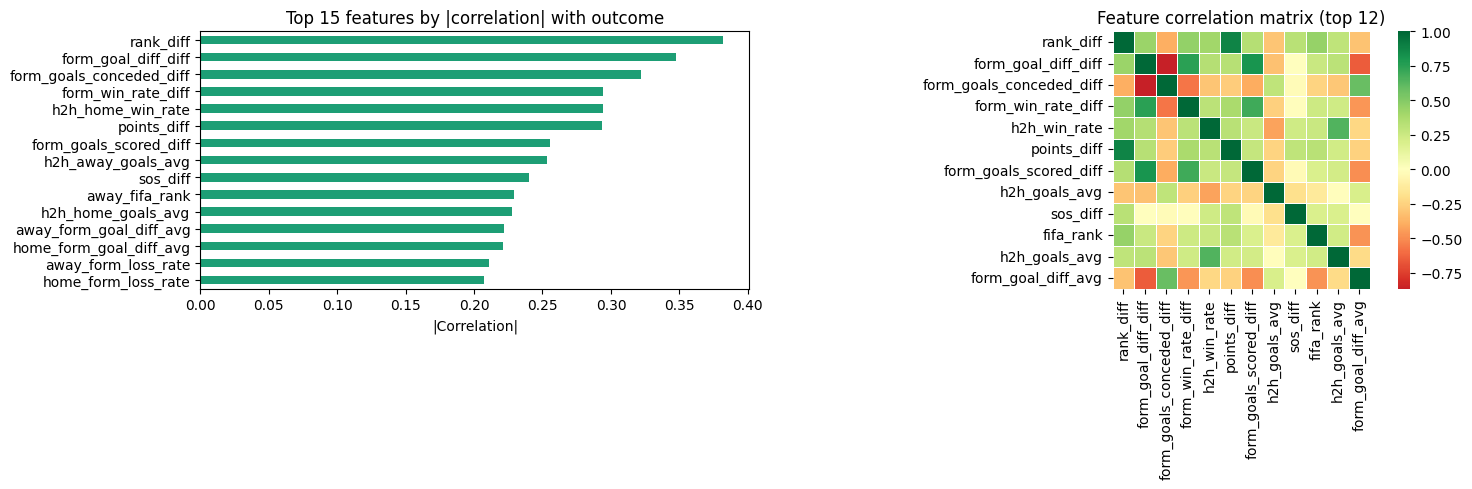


Top features by correlation with outcome:
rank_diff                   0.3821
form_goal_diff_diff         0.3475
form_goals_conceded_diff    0.3220
form_win_rate_diff          0.2943
h2h_home_win_rate           0.2941
points_diff                 0.2936
form_goals_scored_diff      0.2555
h2h_away_goals_avg          0.2529
sos_diff                    0.2401
away_fifa_rank              0.2289
h2h_home_goals_avg          0.2280
away_form_goal_diff_avg     0.2222
home_form_goal_diff_avg     0.2215
away_form_loss_rate         0.2107
home_form_loss_rate         0.2076


In [ ]:
import seaborn as sns

# Encode outcome as numeric for correlation
outcome_num = feat_df[TARGET_COL].map({'H':1,'D':0,'A':-1})

# Top correlations with outcome
corr_with_outcome = feat_df[FEATURE_COLS].corrwith(outcome_num).abs().sort_values(ascending=False)
top_features = corr_with_outcome.head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart: feature importance by correlation
top_features.plot(kind='barh', ax=axes[0], color='#1D9E75')
axes[0].set_title('Top 15 features by |correlation| with outcome')
axes[0].set_xlabel('|Correlation|')
axes[0].invert_yaxis()

# Correlation heatmap of top 12 features
top12 = top_features.index[:12].tolist()
corr_matrix = feat_df[top12].corr()
sns.heatmap(corr_matrix, ax=axes[1], cmap='RdYlGn', center=0,
            annot=False, square=True, linewidths=0.5,
            xticklabels=[c.replace('home_','').replace('away_','') for c in top12],
            yticklabels=[c.replace('home_','').replace('away_','') for c in top12])
axes[1].set_title('Feature correlation matrix (top 12)')

plt.tight_layout()
plt.savefig('data/feature_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nTop features by correlation with outcome:')
print(top_features.round(4).to_string())

## 10. Export feature matrix

In [ ]:
import os, json
os.makedirs('data/processed', exist_ok=True)

# ── Save features ──
feat_df.to_csv('data/processed/features.csv', index=False)

# ── Save feature column list (needed by Notebook 3 and inference) ──
with open('data/processed/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

# ── WC-only feature set ──
wc_feats = feat_df[feat_df['is_world_cup']]
wc_feats.to_csv('data/processed/features_wc_only.csv', index=False)

print('=== EXPORT SUMMARY ===')
print(f'features.csv         → {len(feat_df):,} rows, {len(FEATURE_COLS)} features')
print(f'features_wc_only.csv → {len(wc_feats):,} World Cup matches')
print(f'feature_cols.json    → list of {len(FEATURE_COLS)} feature names')
print()
print('Sample row (Brazil vs France hypothetical):')
sample = feat_df[feat_df['home_team']=='Brazil'].tail(1)[FEATURE_COLS[:8]]
print(sample.to_string())


=== EXPORT SUMMARY ===
features.csv         → 31,929 rows, 38 features
features_wc_only.csv → 992 World Cup matches
feature_cols.json    → list of 38 feature names

Sample row (Brazil vs France hypothetical):
       home_fifa_rank  away_fifa_rank  home_fifa_points  away_fifa_points  rank_diff  points_diff  home_form_win_rate  home_form_draw_rate
31906             5.0            13.0           1788.65           1661.42        8.0       127.23            0.526577             0.047807

✅ Feature engineering complete!
➡️  Next: Notebook 3 — XGBoost training + cross-validation




### What we built and why

| Feature group | Why it matters |
|---|---|
| **FIFA rank / points** | Best single proxy for team quality right now |
| **Time decay** (λ=0.1) | 1930 data barely registers; 2024 data dominates |
| **Competition weight** | WC win signals more than friendly win |
| **Rolling form (10 matches)** | Recent momentum and confidence |
| **Strength of schedule** | Beating top-10 teams means more than beating 150th |
| **Head-to-head (last 5)** | Psychological edge, tactical familiarity |
| **Difference features** | Relative advantage — often strongest XGBoost signals |
| **Confederation** | Tactical styles cluster by region |

